In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LassoCV
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
df = pd.read_csv('../data/advertising.csv', index_col=0)

print("Data loaded ✅")
print("Shape:", df.shape)
df.head()

Data loaded ✅
Shape: (200, 4)


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
total_tv        = df['TV'].sum()
total_radio     = df['Radio'].sum()
total_newspaper = df['Newspaper'].sum()
total_sales     = df['Sales'].sum()

print("=== TOTAL SPEND PER CHANNEL ===")
print()
print(f"TV Spend:        {total_tv:.2f}")
print(f"Radio Spend:     {total_radio:.2f}")
print(f"Newspaper Spend: {total_newspaper:.2f}")
print(f"Total Sales:     {total_sales:.2f}")

=== TOTAL SPEND PER CHANNEL ===

TV Spend:        29408.50
Radio Spend:     4652.80
Newspaper Spend: 6110.80
Total Sales:     2804.50


In [4]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

model = LassoCV(cv=5).fit(X, y)

coefs = dict(zip(X.columns, model.coef_))
total_coef = sum(abs(v) for v in coefs.values())

print("=== CHANNEL CONTRIBUTION ===")
print()
for ch, coef in coefs.items():
    pct = abs(coef) / total_coef * 100
    print(f"{ch}: {pct:.1f}% contribution to sales")

=== CHANNEL CONTRIBUTION ===

TV: 20.2% contribution to sales
Radio: 79.8% contribution to sales
Newspaper: 0.0% contribution to sales


In [5]:
spend = {
    'TV':        total_tv,
    'Radio':     total_radio,
    'Newspaper': total_newspaper
}

print("=== ROI PER CHANNEL ===")
print()
for ch, coef in coefs.items():
    pct        = abs(coef) / total_coef
    attributed = total_sales * pct
    roi        = attributed / spend[ch]
    print(f"{ch}:")
    print(f"  Sales attributed: {attributed:.2f}")
    print(f"  Money spent:      {spend[ch]:.2f}")
    print(f"  ROI:              {roi:.3f}  (higher is better)")
    print()

=== ROI PER CHANNEL ===

TV:
  Sales attributed: 567.77
  Money spent:      29408.50
  ROI:              0.019  (higher is better)

Radio:
  Sales attributed: 2236.73
  Money spent:      4652.80
  ROI:              0.481  (higher is better)

Newspaper:
  Sales attributed: 0.00
  Money spent:      6110.80
  ROI:              0.000  (higher is better)



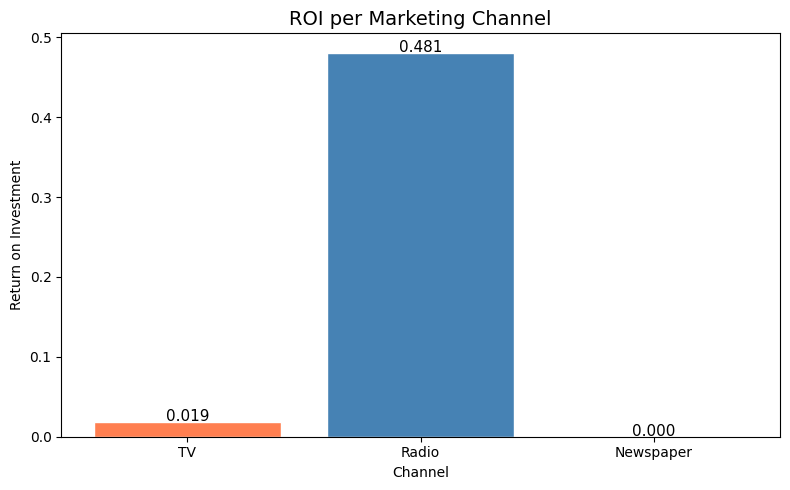

ROI chart saved ✅


In [6]:
channels = list(coefs.keys())
rois = []

for ch in channels:
    pct        = abs(coefs[ch]) / total_coef
    attributed = total_sales * pct
    roi        = attributed / spend[ch]
    rois.append(round(roi, 3))

colors = ['steelblue' if r == max(rois) else 'coral' for r in rois]

plt.figure(figsize=(8, 5))
bars = plt.bar(channels, rois, color=colors, edgecolor='white')
plt.title('ROI per Marketing Channel', fontsize=14)
plt.ylabel('Return on Investment')
plt.xlabel('Channel')

for bar, roi in zip(bars, rois):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{roi:.3f}',
        ha='center', fontsize=11
    )

plt.tight_layout()
plt.savefig('../reports/roi_per_channel.png')
plt.show()
print("ROI chart saved ✅")

In [7]:
best_channel  = channels[rois.index(max(rois))]
worst_channel = channels[rois.index(min(rois))]

print("=== FINAL RECOMMENDATION ===")
print()
print(f"Best channel:  {best_channel} with ROI of {max(rois):.3f}")
print(f"Worst channel: {worst_channel} with ROI of {min(rois):.3f}")
print()
print(f"Recommendation: Increase budget for {best_channel}")
print(f"Recommendation: Reduce budget for {worst_channel}")

=== FINAL RECOMMENDATION ===

Best channel:  Radio with ROI of 0.481
Worst channel: Newspaper with ROI of 0.000

Recommendation: Increase budget for Radio
Recommendation: Reduce budget for Newspaper
